I was curious to know which exogeneous features are most dominant and which are not so trying SHAP analysis. First we will try SHAP with XGboost as it is quick and then confirm our fidnings with SHAP on MSTL, SHAP with MSTL is quite slow, as for one sample, the model runs 100s of times, as it needs to check, changing which feature value has how much effect on the prediction.

In [14]:
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import pandas as pd
import holidays


### Dataset 

We would need to use the same data that we used for MSTL that is the training data and testing data which is one hot encoded. We don't necessarlily need to apply MAD (Median Absolute Deviation) and standard scaling as tree based models are mostly concerned about exogeneous variable's thresholds and are robust to outliers.

In [16]:
# 2022 dataset
ptcw = pd.read_csv("./kafka_coding_2/data/ptc_weather.csv")
ptcw.head(3)

,unique_id,ds,y,year,month,day,hour,in_sum,out_sum,day_of_week,...,humidity_mean,precipitation_mean,rain_mean,snowfall_mean,snow_depth_mean,wind_speed_mean,cloud_cover_mean,cloud_cover_low_mean,cloud_cover_mid_mean,cloud_cover_high_mean
0,all_sensors,2022-01-01 00:00:00,4852.0,2022,1,1,0,2392.0,2460.0,5,...,97.0,0.2,0.1,0.07,0.09,9.4,100.0,100.0,100.0,0.0
1,all_sensors,2022-01-01 01:00:00,4175.0,2022,1,1,1,1907.0,2268.0,5,...,98.0,0.3,0.0,0.21,0.09,4.7,100.0,100.0,100.0,83.0
2,all_sensors,2022-01-01 02:00:00,4016.0,2022,1,1,2,1959.0,2057.0,5,...,99.0,0.0,0.0,0.00,0.09,4.3,100.0,100.0,100.0,21.0


In [17]:
# Adding in the holidays in Estonia as marked by the Holidays library
ee_holidays = holidays.Estonia(years=[2022,2023])
ee_holidays


{datetime.date(2022, 1, 1): 'uusaasta', datetime.date(2022, 2, 24): 'iseseisvuspäev', datetime.date(2022, 4, 15): 'suur reede', datetime.date(2022, 4, 17): 'ülestõusmispühade 1. püha', datetime.date(2022, 6, 5): 'nelipühade 1. püha', datetime.date(2022, 5, 1): 'kevadpüha', datetime.date(2022, 6, 23): 'võidupüha', datetime.date(2022, 6, 24): 'jaanipäev', datetime.date(2022, 8, 20): 'taasiseseisvumispäev', datetime.date(2022, 12, 24): 'jõululaupäev', datetime.date(2022, 12, 25): 'esimene jõulupüha', datetime.date(2022, 12, 26): 'teine jõulupüha', datetime.date(2023, 1, 1): 'uusaasta', datetime.date(2023, 2, 24): 'iseseisvuspäev', datetime.date(2023, 4, 7): 'suur reede', datetime.date(2023, 4, 9): 'ülestõusmispühade 1. püha', datetime.date(2023, 5, 28): 'nelipühade 1. püha', datetime.date(2023, 5, 1): 'kevadpüha', datetime.date(2023, 6, 23): 'võidupüha', datetime.date(2023, 6, 24): 'jaanipäev', datetime.date(2023, 8, 20): 'taasiseseisvumispäev', datetime.date(2023, 12, 24): 'jõululaupäev'

In [18]:
ptcw["ds"] = pd.to_datetime(ptcw["ds"])
ptcw["is_holiday"] = ptcw["ds"].dt.date.map(
    lambda x : 1 if x in ee_holidays else 0
)
ptcw_2022 = ptcw[ptcw["year"]==2022]
# 2023 development dataset, doesn't contain "y"
ptcw_2023_dev = ptcw[ptcw["year"]==2023].drop("y",axis=1)
# 2023 Ground Truth dataset, serves to make the "sliding window" training dataset.
ptc_weather_2023_ground_truth = ptcw[ptcw["year"]==2023]

In [ ]:
# keeping features that we want SHAP to explain 
feature_cols = [
    'temp_mean', 'humidity_mean', 'precipitation_mean', 'rain_mean',
    'snowfall_mean', 'snow_depth_mean', 'wind_speed_mean', 'cloud_cover_mean',
    'cloud_cover_low_mean', 'cloud_cover_mid_mean', 'cloud_cover_high_mean',
    'is_holiday','day','hour','month','day_of_week']

In [22]:
x_train = ptcw_2022[feature_cols]
y_train = ptcw_2022["y"]

x_test = ptcw_2023_dev[feature_cols]
y_test = ptc_weather_2023_ground_truth["y"]

In [ ]:
surrogate = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=1)
surrogate.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = surrogate.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Surrogate MAE:  {mae:.2f}")
print(f"Surrogate RMSE: {rmse:.2f}")

Surrogate MAE:  1666.92
Surrogate RMSE: 2029.37


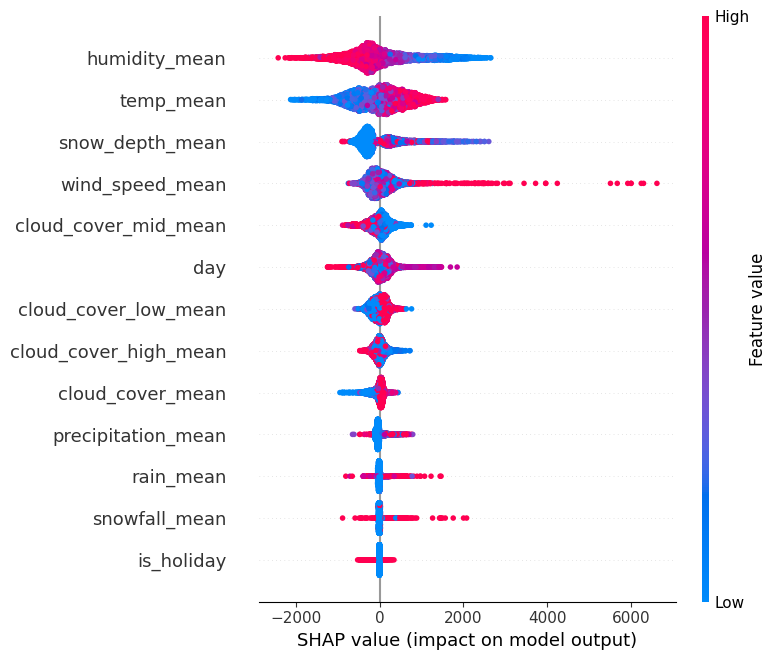

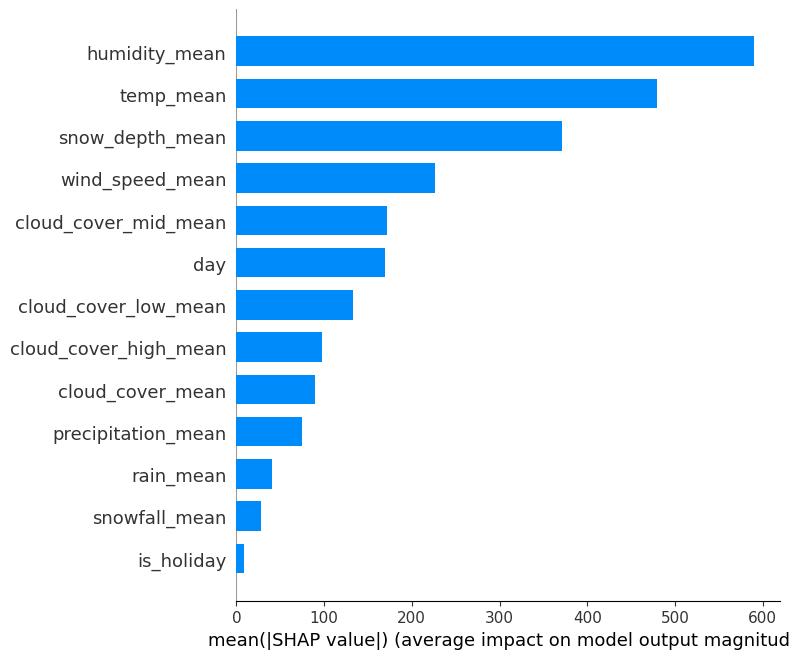

In [24]:
# SHAP analysis
explainer = shap.TreeExplainer(surrogate)
shap_values = explainer.shap_values(x_test)

# Summary plot — shows feature importance + direction of effect
shap.summary_plot(shap_values, x_test, feature_names=feature_cols)

# Bar plot — mean absolute SHAP value per feature
shap.summary_plot(shap_values, x_test, feature_names=feature_cols, plot_type="bar")